# BM3D Denoising Visualization and Metrics Analysis

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import cv2
import os
from IPython.display import Image, display

%matplotlib inline

## 1. Metrics Analysis

In [9]:
df = pd.read_csv('../../results/noise_metrics/denoise_all_metrics_summary.csv')
summary = df.groupby(['method', 'noise_level']).mean(numeric_only=True).reset_index()
display(summary)

,method,noise_level,PSNR,SSIM,MS-SSIM,LPIPS,MAE,MSE,BRISQUE,NIQE,PIQE,Entropy
0,BM3D-config1-mixed,15,29.556880,0.795877,0.795877,0.295262,5.706154,79.865593,26.029700,6.101128,44.253068,6.797483
1,BM3D-config1-mixed,25,29.954522,0.804779,0.804779,0.226303,5.992250,71.130621,17.463879,5.110752,20.981775,6.886902
2,BM3D-config1-mixed,50,19.379997,0.314723,0.314723,0.721517,21.717408,753.524592,60.194513,11.104110,64.861109,7.338188
3,BM3D-config1-specialized,15,32.525130,0.873026,0.873026,0.125448,4.576178,38.186797,13.291028,4.350207,22.847247,6.965961
4,BM3D-config1-specialized,25,29.814061,0.786184,0.786184,0.230296,6.236096,71.829746,20.917615,5.177363,26.935961,6.928946
5,BM3D-config1-specialized,50,26.079946,0.625110,0.625110,0.397839,9.742014,171.979975,35.582947,6.863151,37.261712,6.881696
6,BM3D-config2-mixed,15,27.069880,0.702959,0.702959,0.404840,7.486205,147.518035,49.266858,7.459650,66.313095,6.761890
7,BM3D-config2-mixed,25,27.592135,0.733218,0.733218,0.383391,7.197358,132.176637,30.654065,6.925962,45.753384,6.760220
8,BM3D-config2-mixed,50,25.459471,0.576067,0.576067,0.426596,10.580077,191.632628,39.616016,7.100919,44.236882,6.945069
9,BM3D-config2-specialized,15,32.209494,0.857611,0.857611,0.130215,4.815241,40.496256,15.502283,4.488137,25.579943,6.995803


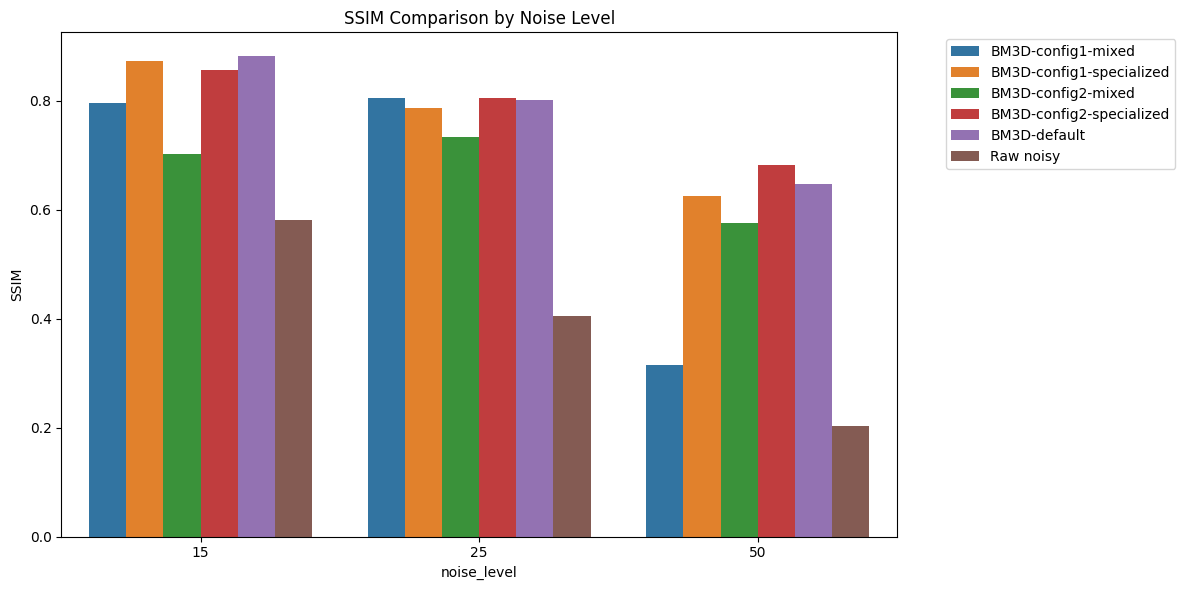

In [10]:
plt.figure(figsize=(12, 6))
sns.barplot(data=summary, x='noise_level', y='SSIM', hue='method')
plt.title('SSIM Comparison by Noise Level')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

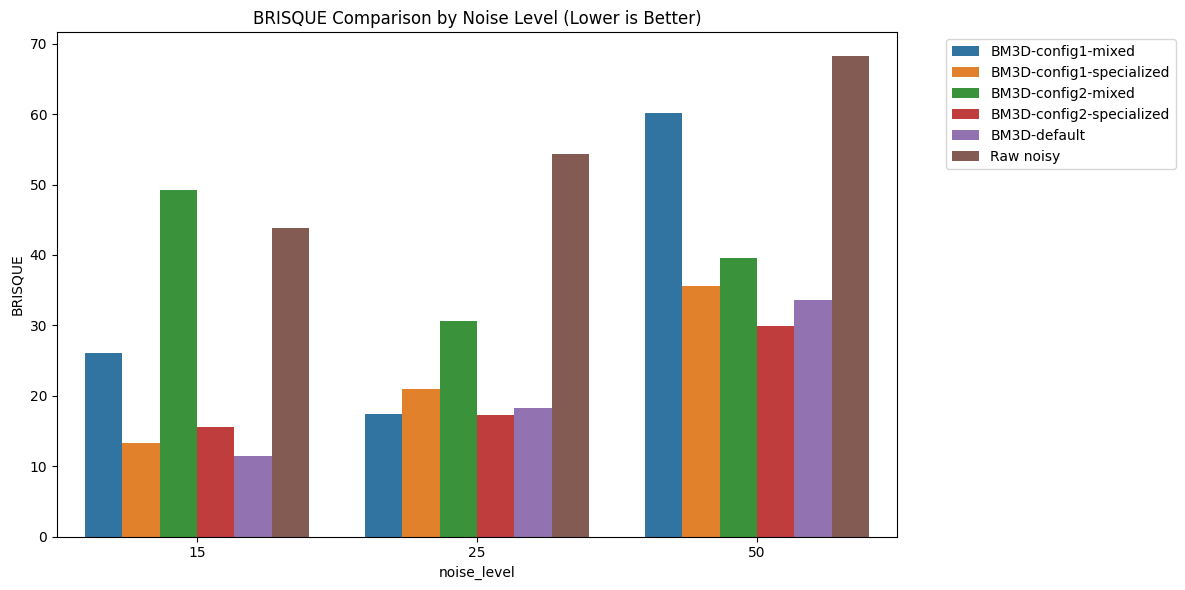

In [11]:
plt.figure(figsize=(12, 6))
sns.barplot(data=summary, x='noise_level', y='BRISQUE', hue='method')
plt.title('BRISQUE Comparison by Noise Level (Lower is Better)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 2. Visual Comparisons

In [ ]:
def show_images(noise_level, img_id):
    base_dir = f'../../results/figures/denoise_visual_comparison/noise{noise_level}'
    if not os.path.exists(base_dir):
        print(f"No visual results found for noise {noise_level}")
        return
        
    methods = [
        'clean',
        'raw_noisy',
        'BM3D_default',
        'BM3D_config1_specialized',
        'BM3D_config2_specialized',
        'BM3D_config1_mixed',
        'BM3D_config2_mixed'
    ]
    
    plt.figure(figsize=(20, 10))
    for i, method in enumerate(methods):
        img_path = os.path.join(base_dir, f"{img_id}_{method}.png")
        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(2, 4, i+1)
            plt.imshow(img)
            plt.title(method)
            plt.axis('off')
            
    plt.tight_layout()
    plt.show()

show_images(15, '0015.png')  # Replace with actual image ID